In [1]:
import nltk
from readability import Readability
from readability.exceptions import ReadabilityException
from textblob import TextBlob

# 1. Download NLTK data (Required if running manually)
try:
    nltk.download('punkt_tab', quiet=True)
except:
    nltk.download('punkt', quiet=True)

In [2]:
text = "Somali sisters, Iman and Siham Hashi, make up Faarrow .\nA fusion of hip-hop, world pop and Afrobeats, they are currently finishing debut album ."

r = Readability(text)
def get_flesch_kincaid(r: Readability):
    stats = r._statistics
    return (0.38 * stats.avg_words_per_sentence +
                11.8 * stats.avg_syllables_per_word) - 15.59

def get_flesch(r: Readability):
    stats = r._statistics
    words_per_sent = stats.num_words / stats.num_sentences
    syllables_per_word = stats.num_syllables / stats.num_words
    return 206.835 - (1.015 * words_per_sent) - (84.6 * syllables_per_word)

def get_dale_chall(r: Readability):
    stats = r._statistics
    words_per_sent = stats.num_words / stats.num_sentences
    percent_difficult_words = \
        stats.num_dale_chall_complex / stats.num_words * 100
    raw_score = 0.1579 * percent_difficult_words + 0.0496 * words_per_sent
    adjusted_score = raw_score + 3.6365 \
        if percent_difficult_words > 5 \
        else raw_score
    return adjusted_score

def get_coleman_liau(r: Readability):
    s = r._statistics
    scalar = s.num_words / 100
    letters_per_100_words = s.num_letters / scalar
    sentences_per_100_words = s.num_sentences / scalar
    return 0.0588 * letters_per_100_words - \
        0.296 * sentences_per_100_words - 15.8

def get_gunning_fog(r: Readability):
    s = r._statistics
    word_per_sent = s.num_words / s.num_sentences
    poly_syllables_per_word = s.num_gunning_complex / s.num_words
    return 0.4 * (word_per_sent + 100 * poly_syllables_per_word)

print("FKGL Score:", get_flesch_kincaid(r))
print("Flesch Score:", get_flesch(r))
print("Dale-Chall Score:", get_dale_chall(r))
print("Coleman-Liau Score:", get_coleman_liau(r))
print("Gunning Fog Score:", get_gunning_fog(r))



FKGL Score: 9.301739130434786
Flesch Score: 48.032065217391334
Dale-Chall Score: 11.758639130434783
Coleman-Liau Score: 10.770434782608692
Gunning Fog Score: 8.078260869565218


In [3]:
def average_fk_from_file(path: str):
    total = 0.0
    count = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                r = Readability(line)
                score = get_flesch_kincaid(r)
                total += score
                count += 1
            except Exception:
                # line may be too short to compute stats; skip
                continue

    if count == 0:
        return None  # or float('nan') if you prefer

    return total / count

In [6]:
print(average_fk_from_file("asset_orig.txt"))
print(average_fk_from_file("asset_output_T5.txt"))
print(average_fk_from_file("asset_output_bert.txt"))


11.833103723911135
7.901026560151653
9.726472036783663


In [4]:
from textblob import TextBlob
from readability import Readability

def compute_averages_from_file(path: str, alpha: float = 0.5, target_flesch: float = 90.0):
    """
    Reads a file containing one summary per line.
    Computes:
        - average normalized Flesch score (relative to target 90)
        - average bias (1 - subjectivity)
        - average weighted score (alpha * FS + (1-alpha) * bias)
    Returns a tuple: (avg_flesch, avg_bias, avg_weighted)
    """

    summaries = []
    with open(path, "r", encoding="utf-8") as f:
        summaries = [line.strip() for line in f if line.strip()]

    flesch_scores = []
    biases = []
    weighted_scores = []

    for text in summaries:
        # Compute Flesch score
        try:
            fs = get_flesch(Readability(text))
        except:
            fs = 100  # fallback
        # Normalize relative to target
        fs_norm = 1 - (abs(fs - target_flesch) / 100)
        flesch_scores.append(fs_norm)

        # Compute bias
        try:
            testimonial = TextBlob(text)
            bias = 1 - testimonial.sentiment.subjectivity
        except:
            bias = 1.0
        biases.append(bias)

        # Weighted combination
        weighted_scores.append(alpha * fs_norm + (1 - alpha) * bias)

    # Compute averages
    avg_flesch = sum(flesch_scores) / len(flesch_scores) if flesch_scores else 0
    avg_bias = sum(biases) / len(biases) if biases else 0
    avg_weighted = sum(weighted_scores) / len(weighted_scores) if weighted_scores else 0

    return avg_flesch, avg_bias, avg_weighted


Baseline FGKL

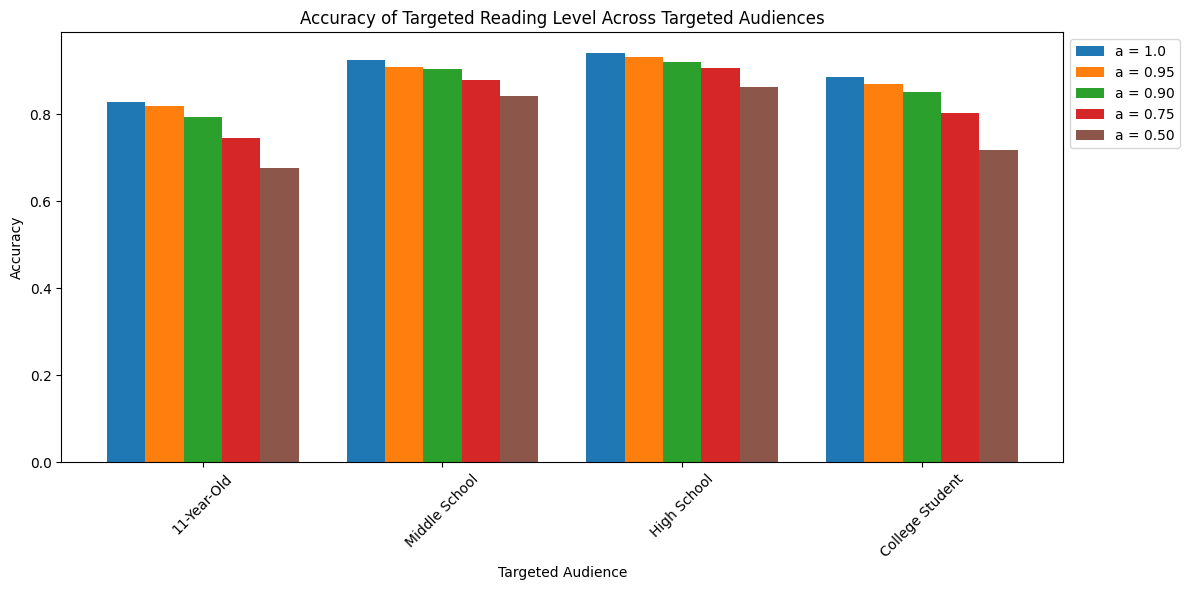

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Data ----
groups = {
    "11-Year-Old": ["11yold_test.txt", "11yold_test_bias95.txt", "11yold_test_bias90.txt", "11yold_test_bias75.txt", "11yold_test_bias.txt"],
    "Middle School": ["middle-school.txt", "middle-school_bias95.txt", "middle-school_bias90.txt", "middle-school_bias75.txt", "middle-school_bias.txt"],
    "High School": ["high-school.txt", "high-school_bias95.txt", "high-school_bias90.txt", "high-school_bias75.txt", "high-school_bias.txt"],
    "College Student": ["college-student.txt", "college-student_bias95.txt", "college-student_bias90.txt", "college-student_bias75.txt", "college-student_bias.txt"],
}

target_scores = {
    "11yold_test.txt": 90.0,      "11yold_test_bias95.txt": 90.0, "11yold_test_bias90.txt": 90.0,
    "11yold_test_bias75.txt": 90.0, "11yold_test_bias.txt": 90.0,
    "middle-school.txt": 70.0,    "middle-school_bias95.txt": 70.0, "middle-school_bias90.txt": 70.0,
    "middle-school_bias75.txt": 70.0, "middle-school_bias.txt": 70.0,
    "high-school.txt": 50.0,      "high-school_bias95.txt": 50.0, "high-school_bias90.txt": 50.0,
    "high-school_bias75.txt": 50.0, "high-school_bias.txt": 50.0,
    "college-student.txt": 30.0,  "college-student_bias95.txt": 30.0, "college-student_bias90.txt": 30.0,
    "college-student_bias75.txt": 30.0, "college-student_bias.txt": 30.0,
}

labels = list(groups.keys())
num_groups = len(labels)

# α values (in order matching paths)
alphas = [1.0, 0.95, 0.90, 0.75, 0.50]

fk_values_by_group = []
max_versions = 5

# ---- Compute only endpoints & interpolate ----
fk_values_by_group = []

for group, paths in groups.items():
    group_values = []
    for path, a in zip(paths, alphas):
        target = target_scores[path]
        fk_val, _, _ = compute_averages_from_file(path, alpha=a, target_flesch=target)
        group_values.append(fk_val)

    fk_values_by_group.append(group_values)


# ---- Plot ----
plt.figure(figsize=(12, 6))
x = np.arange(num_groups)
bar_width = 0.8 / max_versions

version_labels = ["a = 1.0", "a = 0.95", "a = 0.90", "a = 0.75", "a = 0.50"]
version_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#8c564b"]

for version_idx in range(max_versions):
    xs = x + version_idx * bar_width
    vals = [fk_values_by_group[g][version_idx] for g in range(num_groups)]
    plt.bar(xs, vals, width=bar_width, color=version_colors[version_idx],
            label=version_labels[version_idx])

plt.xlabel("Targeted Audience")
plt.ylabel("Accuracy")
plt.title("Accuracy of Targeted Reading Level Across Targeted Audiences")

plt.xticks(x + bar_width * (max_versions - 1) / 2, labels, rotation=45)

plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


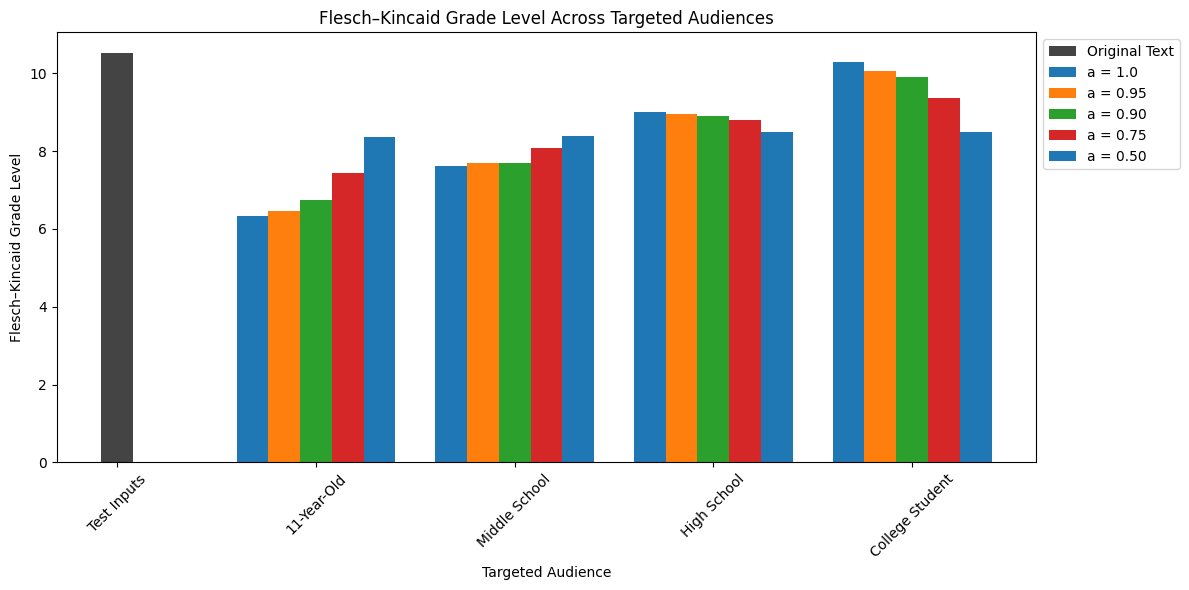

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Data ----
groups = {
    "11-Year-Old": ["11yold_test.txt", "11yold_test_bias95.txt", "11yold_test_bias90.txt", "11yold_test_bias75.txt", "11yold_test_bias.txt", ],
    "Middle School": ["middle-school.txt", "middle-school_bias95.txt", "middle-school_bias90.txt", "middle-school_bias75.txt", "middle-school_bias.txt"],
    "High School": ["high-school.txt", "high-school_bias95.txt", "high-school_bias90.txt", "high-school_bias75.txt", "high-school_bias.txt"],
    "College Student": ["college-student.txt", "college-student_bias95.txt", "college-student_bias90.txt", "college-student_bias75.txt", "college-student_bias.txt"],
}

# Per-file target Flesch scores
target_scores = {
    "11yold_test.txt": 90.0,
    "11yold_test_bias.txt": 90.0,
    "11yold_test_bias75.txt": 90.0,
    "11yold_test_bias90.txt": 90.0,
    "11yold_test_bias95.txt": 90.0,
    "middle-school.txt": 70.0,
    "middle-school_bias.txt": 70.0,
    "middle-school_bias75.txt": 70.0,
    "middle-school_bias90.txt": 70.0,
    "middle-school_bias95.txt": 70.0,
    "high-school.txt": 50.0,
    "high-school_bias.txt": 50.0,
    "high-school_bias75.txt": 50.0,
    "high-school_bias90.txt": 50.0,
    "high-school_bias95.txt": 50.0,
    "college-student.txt": 30.0,
    "college-student_bias.txt": 30.0,
    "college-student_bias75.txt": 30.0,
    "college-student_bias90.txt": 30.0,
    "college-student_bias95.txt": 30.0,
}

labels = list(groups.keys())
num_groups = len(labels)

fk_values_by_group = []
max_versions = 0

# ---- Compute weighted averages per file ----
for group, paths in groups.items():
    max_versions = max(max_versions, len(paths))
    version_values = []
    for path in paths:
        target = target_scores.get(path, 90.0)  # default if not specified
        avg_flesch, avg_bias, avg_weighted = compute_averages_from_file(
            path, alpha=0.5, target_flesch=target
        )
        version_values.append(avg_flesch)
    fk_values_by_group.append(version_values)

# ---- Plot ----
plt.figure(figsize=(12, 6))
x = np.arange(num_groups)
version_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bar_width = 0.8 / max_versions

# Custom labels for versions
version_labels = ["a = 1.0", "a = 0.95", "a = 0.90", "a = 0.75", "a = 0.50"]

# Plot all versions
for version_idx in range(max_versions):
    vals = []
    xs = []
    for group_idx in range(num_groups):
        group_vals = fk_values_by_group[group_idx]
        if version_idx < len(group_vals):
            vals.append(group_vals[version_idx])
        else:
            vals.append(0)
        xs.append(group_idx + version_idx * bar_width)

    plt.bar(
        xs,
        vals,
        width=bar_width,
        color=version_colors[version_idx % len(version_colors)],
        label=version_labels[version_idx]
    )

plt.xlabel("Targeted Audience")
plt.ylabel("Accuracy")
plt.title("Accuracy of Targeted Reading Level Across Targeted Audiences")

# Center x-ticks under groups
plt.xticks(
    x + bar_width * (max_versions - 1) / 2,
    labels,
    rotation=45
)

# Legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


Baseline Bias

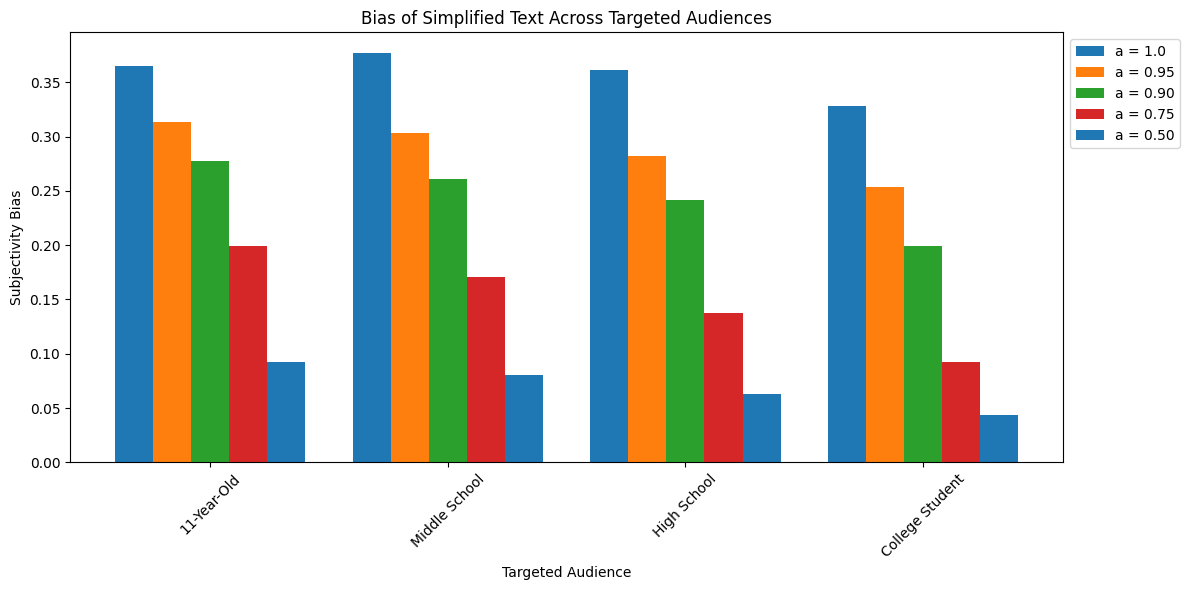

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Data ----
groups = {
    "11-Year-Old": ["11yold_test.txt", "11yold_test_bias95.txt", "11yold_test_bias90.txt", "11yold_test_bias75.txt", "11yold_test_bias.txt", ],
    "Middle School": ["middle-school.txt", "middle-school_bias95.txt", "middle-school_bias90.txt", "middle-school_bias75.txt", "middle-school_bias.txt"],
    "High School": ["high-school.txt", "high-school_bias95.txt", "high-school_bias90.txt", "high-school_bias75.txt", "high-school_bias.txt"],
    "College Student": ["college-student.txt", "college-student_bias95.txt", "college-student_bias90.txt", "college-student_bias75.txt", "college-student_bias.txt"],
}

# Per-file target Flesch scores
target_scores = {
    "11yold_test.txt": 90.0,
    "11yold_test_bias.txt": 90.0,
    "11yold_test_bias75.txt": 90.0,
    "11yold_test_bias90.txt": 90.0,
    "11yold_test_bias95.txt": 90.0,
    "middle-school.txt": 70.0,
    "middle-school_bias.txt": 70.0,
    "middle-school_bias75.txt": 70.0,
    "middle-school_bias90.txt": 70.0,
    "middle-school_bias95.txt": 70.0,
    "high-school.txt": 50.0,
    "high-school_bias.txt": 50.0,
    "high-school_bias75.txt": 50.0,
    "high-school_bias90.txt": 50.0,
    "high-school_bias95.txt": 50.0,
    "college-student.txt": 30.0,
    "college-student_bias.txt": 30.0,
    "college-student_bias75.txt": 30.0,
    "college-student_bias90.txt": 30.0,
    "college-student_bias95.txt": 30.0,
}

labels = list(groups.keys())
num_groups = len(labels)

fk_values_by_group = []
max_versions = 0

# ---- Compute weighted averages per file ----
for group, paths in groups.items():
    max_versions = max(max_versions, len(paths))
    version_values = []
    for path in paths:
        target = target_scores.get(path, 90.0)  # default if not specified
        avg_flesch, avg_bias, avg_weighted = compute_averages_from_file(
            path, alpha=0.5, target_flesch=target
        )
        version_values.append(1-avg_bias)
    fk_values_by_group.append(version_values)

# ---- Plot ----
plt.figure(figsize=(12, 6))
x = np.arange(num_groups)
version_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bar_width = 0.8 / max_versions

# Custom labels for versions
version_labels = ["a = 1.0", "a = 0.95", "a = 0.90", "a = 0.75", "a = 0.50"]

# Plot all versions
for version_idx in range(max_versions):
    vals = []
    xs = []
    for group_idx in range(num_groups):
        group_vals = fk_values_by_group[group_idx]
        if version_idx < len(group_vals):
            vals.append(group_vals[version_idx])
        else:
            vals.append(0)
        xs.append(group_idx + version_idx * bar_width)

    plt.bar(
        xs,
        vals,
        width=bar_width,
        color=version_colors[version_idx % len(version_colors)],
        label=version_labels[version_idx]
    )

plt.xlabel("Targeted Audience")
plt.ylabel("Subjectivity Bias")
plt.title("Bias of Simplified Text Across Targeted Audiences")

# Center x-ticks under groups
plt.xticks(
    x + bar_width * (max_versions - 1) / 2,
    labels,
    rotation=45
)

# Legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


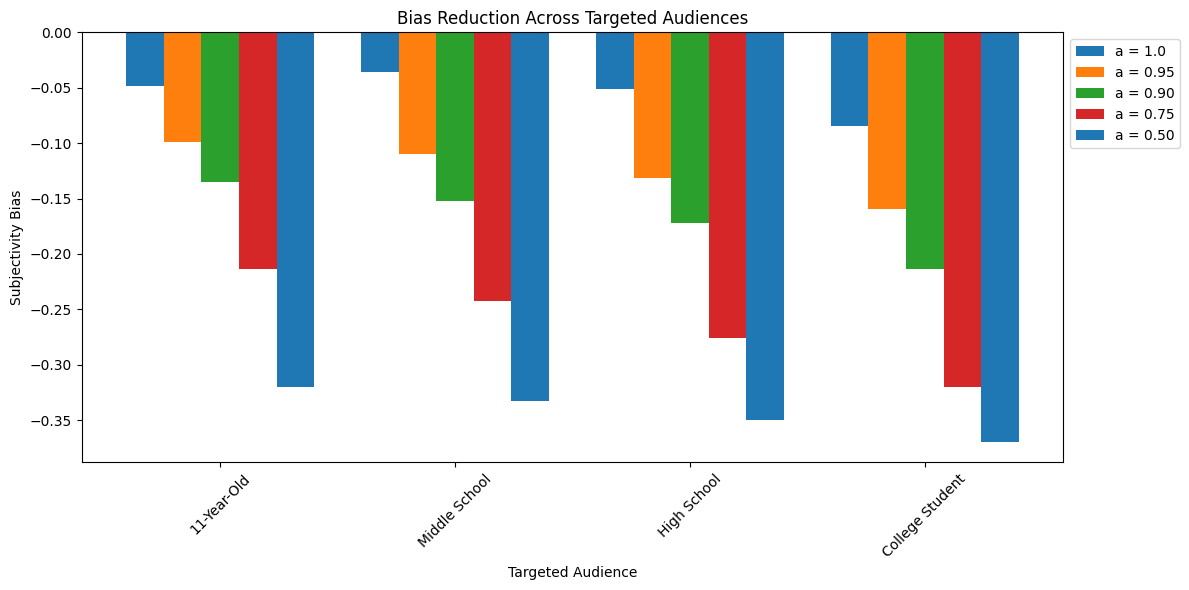

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Data ----
groups = {
    "11-Year-Old": ["11yold_test.txt", "11yold_test_bias95.txt", "11yold_test_bias90.txt", "11yold_test_bias75.txt", "11yold_test_bias.txt", ],
    "Middle School": ["middle-school.txt", "middle-school_bias95.txt", "middle-school_bias90.txt", "middle-school_bias75.txt", "middle-school_bias.txt"],
    "High School": ["high-school.txt", "high-school_bias95.txt", "high-school_bias90.txt", "high-school_bias75.txt", "high-school_bias.txt"],
    "College Student": ["college-student.txt", "college-student_bias95.txt", "college-student_bias90.txt", "college-student_bias75.txt", "college-student_bias.txt"],
}

# Per-file target Flesch scores
target_scores = {
    "11yold_test.txt": 90.0,
    "11yold_test_bias.txt": 90.0,
    "11yold_test_bias75.txt": 90.0,
    "11yold_test_bias90.txt": 90.0,
    "11yold_test_bias95.txt": 90.0,
    "middle-school.txt": 70.0,
    "middle-school_bias.txt": 70.0,
    "middle-school_bias75.txt": 70.0,
    "middle-school_bias90.txt": 70.0,
    "middle-school_bias95.txt": 70.0,
    "high-school.txt": 50.0,
    "high-school_bias.txt": 50.0,
    "high-school_bias75.txt": 50.0,
    "high-school_bias90.txt": 50.0,
    "high-school_bias95.txt": 50.0,
    "college-student.txt": 30.0,
    "college-student_bias.txt": 30.0,
    "college-student_bias75.txt": 30.0,
    "college-student_bias90.txt": 30.0,
    "college-student_bias95.txt": 30.0,
}

labels = list(groups.keys())
num_groups = len(labels)

fk_values_by_group = []
max_versions = 0

# ---- Compute weighted averages per file ----
for group, paths in groups.items():
    max_versions = max(max_versions, len(paths))
    version_values = []
    for path in paths:
        target = target_scores.get(path, 90.0)  # default if not specified
        avg_flesch, avg_bias, avg_weighted = compute_averages_from_file(
            path, alpha=0.5, target_flesch=target
        )
        version_values.append(1-avg_bias)
    fk_values_by_group.append(version_values)

# ---- Plot ----
plt.figure(figsize=(12, 6))
x = np.arange(num_groups)
version_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bar_width = 0.8 / max_versions

# Custom labels for versions
version_labels = ["a = 1.0", "a = 0.95", "a = 0.90", "a = 0.75", "a = 0.50"]

# Plot all versions
for version_idx in range(max_versions):
    vals = []
    xs = []
    for group_idx in range(num_groups):
        group_vals = fk_values_by_group[group_idx]
        if version_idx < len(group_vals):
            vals.append(group_vals[version_idx]-0.413)
        else:
            vals.append(0)
        xs.append(group_idx + version_idx * bar_width)

    plt.bar(
        xs,
        vals,
        width=bar_width,
        color=version_colors[version_idx % len(version_colors)],
        label=version_labels[version_idx]
    )

plt.xlabel("Targeted Audience")
plt.ylabel("Subjectivity Bias")
plt.title("Bias Reduction Across Targeted Audiences")

# Center x-ticks under groups
plt.xticks(
    x + bar_width * (max_versions - 1) / 2,
    labels,
    rotation=45
)

# Legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [8]:
print(compute_averages_from_file("test_inputs.txt", alpha=0.5, target_flesch = 90.0))
print(compute_averages_from_file("11yold_test.txt", alpha=0.5, target_flesch = 90.0))
print(compute_averages_from_file("middle-school.txt", alpha=0.5, target_flesch = 90.0))
print(compute_averages_from_file("high-school.txt", alpha=0.5, target_flesch = 90.0))
print(compute_averages_from_file("college-student.txt", alpha=0.5, target_flesch = 90.0))

(0.6349390192604659, 0.587220675901611, 0.6110798475810384)
(0.827662245513008, 0.6354087015781287, 0.7315354735455684)
(0.7394544060541786, 0.6229430091626297, 0.6811987076084042)
(0.6238017210795908, 0.6384312476874977, 0.6311164843835442)
(0.5072868528592732, 0.6719469987073111, 0.5896169257832922)


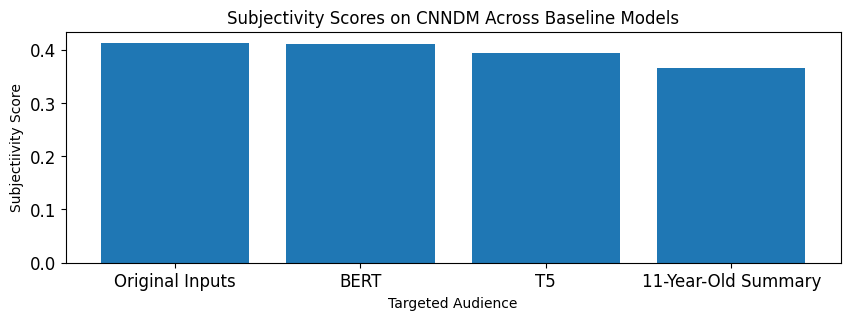

In [16]:
import matplotlib.pyplot as plt

# Your values
values = [0.413, 0.410, 0.393, 0.365]

# Labels for each bar
labels = ["Original Inputs", "BERT", "T5", "11-Year-Old Summary"]

# Make the plot
plt.figure(figsize=(10,3))
plt.bar(labels, values)

plt.title("Subjectivity Scores on CNNDM Across Baseline Models")
# Customize
plt.xlabel("Targeted Audience")
plt.ylabel("Subjectiivity Score")

# Optional: Adjust tick font sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


# Show it
plt.show()
